In [ ]:
import pickle

In [1]:

lib_path = 'model_data/robmods/rob_gpt_training_library.pkl'

with open(lib_path, 'rb') as file:
    lib = pickle.load(file)




Theoretical parameters calculated and added to summary_df.
Index(['n_embd', 'n_layer', 'n_head', 'd_ff', 'vocab_size', 'block_size',
       'use_mup', 'dropout', 'epochs', 'params', 'mean_val_loss',
       'mean_tr_loss', 'tok_per_sec', 'train_time', 'mem_mb', 'lr',
       'params_theory'],
      dtype='object')
Model
tiny      2.253186
small     1.916832
medium    1.553760
large     1.437510
xl        1.371695
Name: mean_tr_loss, dtype: float64
Model
tiny      1.071617
small     0.976643
medium    0.885659
large     0.853211
xl        0.837534
Name: mean_val_loss, dtype: float64
1.7065965218529586
0.9300045967102051


In [2]:
#ifit bayesian scaling law
model, idata = lib.fit_scaling_law_mcmc_series(mup=0, real_param_count=True)



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, a, c, sigma]


/Users/acg/Desktop/ML/SVG/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


/Users/acg/Desktop/ML/SVG/.venv/lib/python3.13/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


--- Scaling Law Results ---
Fitted Alpha (α): 0.0766
Fitted Scale (a): 3.2663


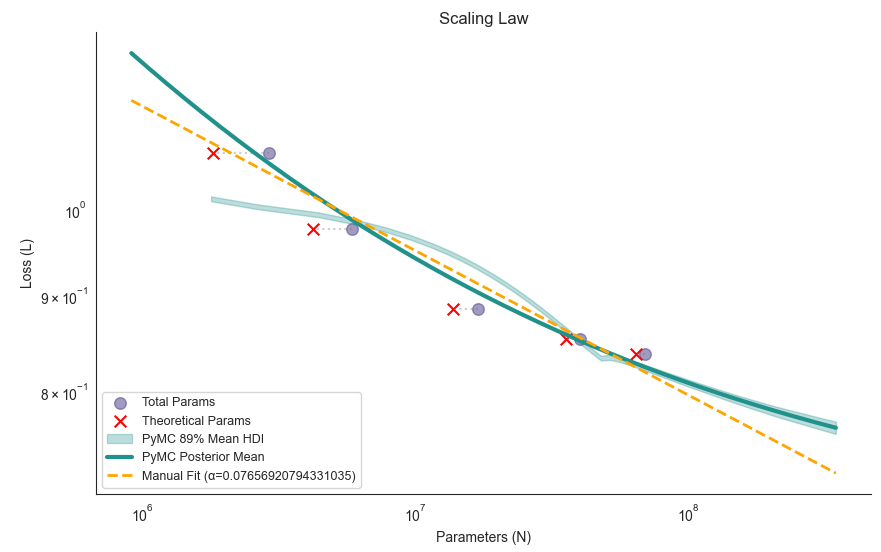

In [3]:

alpha, a = lib.fit_scaling_law_manual(mup=0)
lib.plot_scaling_law_full(idata, alpha, a, mup=0, filepref="orig_gpt")

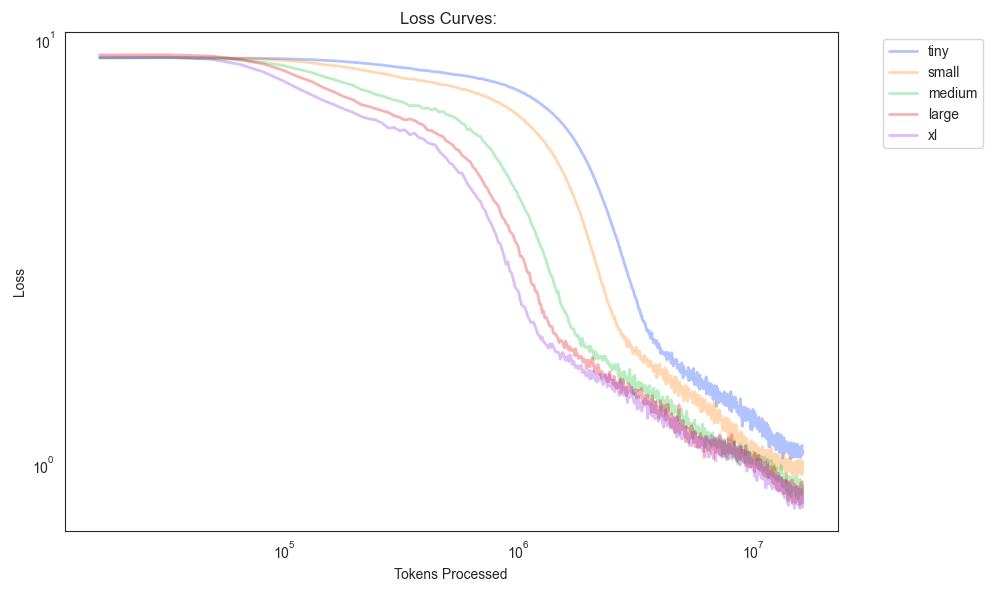

In [4]:
lib.plt_loss_curves(mup=0, filepref="orig_gpt_")

Sampling: [obs]


/Users/acg/Desktop/ML/SVG/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/acg/Desktop/ML/SVG/.venv/lib/python3.13/site-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/acg/Desktop/ML/SVG/.venv/lib/python3.13/site-packages/arviz/stats/stats.py:606: RuntimeWarning: invalid value encountered in subtract
  interval_width = np.subtract(ary[interval_idx_inc:], ary[:n_intervals], dtype=np.float64)
/Users/acg/Desktop/ML/SVG/gpt_library.py:431: RuntimeWarning: divide by zero encountered in power
  manual_mu = a_man * N_grid ** (-alpha_man)


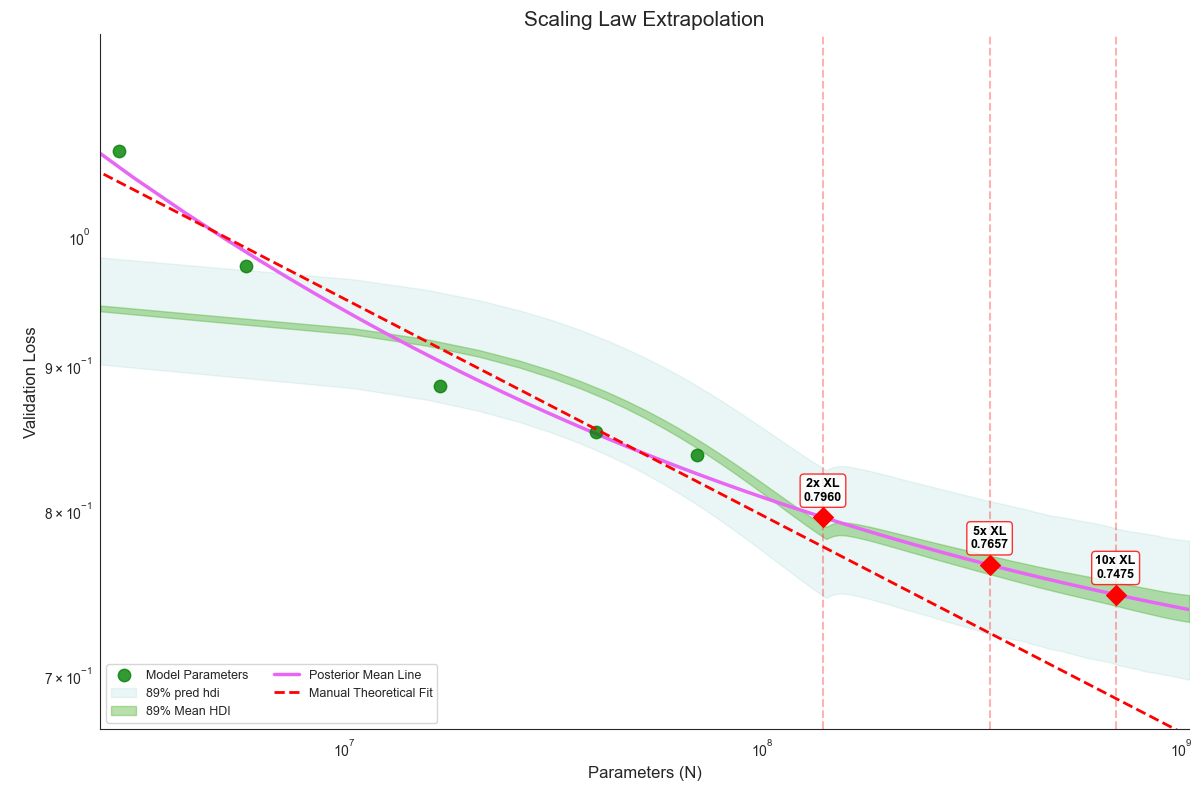

In [5]:

lib.plot_scaling_law_extrapolation(model, idata, alpha, a, mup=0, filepref="b_extrap")